  customerID  gender  SeniorCitizen  tenure PhoneService InternetService  \
0  CUST-0032    Male              0    21.0          YES     Fiber optic   
1  CUST-0110    Male              0    55.0          YES     Fiber optic   
2  CUST-0919  Female              0     8.0          Yes             DSl   
3  CUST-0298    Male              0    51.0          yes     Fiber optic   
4  CUST-0871    Male              0     5.0          yes             DSL   

         Contract PaperlessBilling     PaymentMethod  MonthlyCharges  \
0  Month-to-month               No     Credit card             29.73   
1        Two year              Yes     Bank transfer           46.32   
2  month to month               No  Electronic check           39.69   
3  Month-to-month              yEs      Mailed check           67.12   
4  Month-to-month              Yes    Mailed check             57.59   

   TotalCharges Churn  
0        600.01   Yes  
1       2515.48    No  
2        309.79   Yes  
3       3591.4

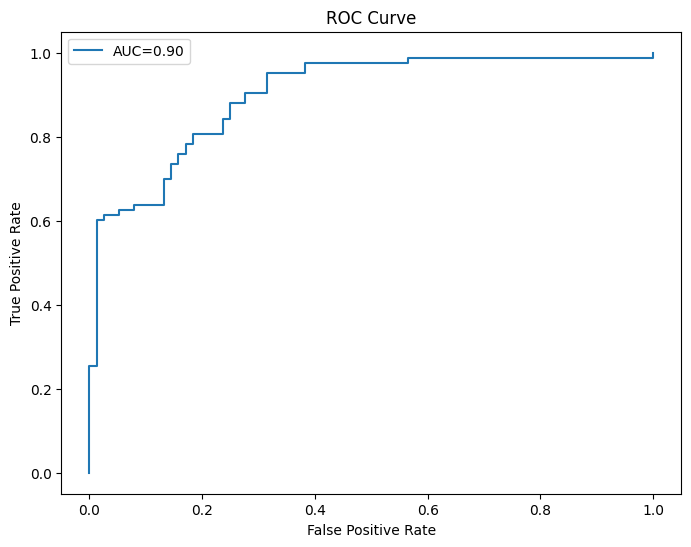

AUC Score: 0.9004438807863031

Threshold: 0.3
Precision: 0.7669902912621359
Recall: 0.9518072289156626
F1 Score: 0.8494623655913979

Threshold: 0.4
Precision: 0.7888888888888889
Recall: 0.8554216867469879
F1 Score: 0.8208092485549133

Threshold: 0.5
Precision: 0.8227848101265823
Recall: 0.7831325301204819
F1 Score: 0.8024691358024691

Threshold: 0.6
Precision: 0.8548387096774194
Recall: 0.6385542168674698
F1 Score: 0.7310344827586207

Threshold: 0.7
Precision: 0.9622641509433962
Recall: 0.6144578313253012
F1 Score: 0.75
Strong Regularization AUC: 0.8766645529486365
Mean AUC Difference: 0.02362587591864619
2.5 Percentile: 0.007930630479650026
97.5 Percentile: 0.04078433760842393


In [7]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score
)

df = pd.read_csv('/content/Cleaned_data.csv')

print(df.head())
print(df.shape)

# =========================
# ENCODING
# =========================
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# =========================
# DEFINE TARGETS
# =========================
# Regression target
y_reg = df['tenure']

# Classification target
y_clf = (df['tenure'] > df['tenure'].median()).astype(int)

# Features
X = df.drop(['tenure'], axis=1)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# LINEAR REGRESSION
# =========================
lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)

y_pred_reg = lr.predict(X_test_scaled)

mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("Linear Regression MSE:", mse)
print("Linear Regression R2:", r2)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

print(coef_df)

# =========================
# RIDGE REGRESSION
# =========================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_reg_test, ridge_pred)
ridge_r2 = r2_score(y_reg_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge R2:", ridge_r2)

# =========================
# LOGISTIC REGRESSION
# =========================
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_clf_train)

y_pred_clf = log_model.predict(X_test_scaled)

print(confusion_matrix(y_clf_test, y_pred_clf))
print(classification_report(y_clf_test, y_pred_clf))

# =========================
# ROC CURVE
# =========================
y_probs = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_clf_test, y_probs)
auc_score = roc_auc_score(y_clf_test, y_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC={auc_score:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

# =========================
# THRESHOLD TESTING
# =========================
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    preds = (y_probs >= t).astype(int)

    precision = precision_score(y_clf_test, preds)
    recall = recall_score(y_clf_test, preds)
    f1 = f1_score(y_clf_test, preds)

    print(f"\nThreshold: {t}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

# =========================
# STRONG REGULARIZATION
# =========================
log_model2 = LogisticRegression(C=0.01, max_iter=1000)
log_model2.fit(X_train_scaled, y_clf_train)

y_probs2 = log_model2.predict_proba(X_test_scaled)[:,1]

auc_score2 = roc_auc_score(y_clf_test, y_probs2)

print("Strong Regularization AUC:", auc_score2)

# =========================
# BOOTSTRAP AUC DIFFERENCE
# =========================
diffs = []

for i in range(500):
    idx = np.random.choice(len(y_clf_test), size=len(y_clf_test), replace=True)

    sample_true = y_clf_test.iloc[idx]
    sample_prob1 = y_probs[idx]
    sample_prob2 = y_probs2[idx]

    auc1 = roc_auc_score(sample_true, sample_prob1)
    auc2 = roc_auc_score(sample_true, sample_prob2)

    diffs.append(auc1 - auc2)

print("Mean AUC Difference:", np.mean(diffs))
print("2.5 Percentile:", np.percentile(diffs, 2.5))
print("97.5 Percentile:", np.percentile(diffs, 97.5))

In [8]:
# ===============================
# PART 3 - ADVANCED MODELING
# ===============================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import joblib

# ==========================================
# TASK 1 - Decision Tree Baseline
# ==========================================

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_clf_train)

train_acc = dt.score(X_train_scaled, y_clf_train)
test_acc = dt.score(X_test_scaled, y_clf_test)

print("Decision Tree Train Accuracy:", train_acc)
print("Decision Tree Test Accuracy:", test_acc)


# ==========================================
# TASK 2 - Controlled Decision Tree
# ==========================================

dt_control = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

dt_control.fit(X_train_scaled, y_clf_train)

train_acc_control = dt_control.score(X_train_scaled, y_clf_train)
test_acc_control = dt_control.score(X_test_scaled, y_clf_test)

print("\nControlled Decision Tree")
print("Train Accuracy:", train_acc_control)
print("Test Accuracy:", test_acc_control)


# ==========================================
# TASK 3 - Gini vs Entropy
# ==========================================

dt_gini = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=42
)

dt_entropy = DecisionTreeClassifier(
    max_depth=5,
    criterion='entropy',
    random_state=42
)

dt_gini.fit(X_train_scaled, y_clf_train)
dt_entropy.fit(X_train_scaled, y_clf_train)

gini_acc = dt_gini.score(X_test_scaled, y_clf_test)
entropy_acc = dt_entropy.score(X_test_scaled, y_clf_test)

print("\nGini Accuracy:", gini_acc)
print("Entropy Accuracy:", entropy_acc)


# ==========================================
# TASK 4 - Random Forest
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_scaled, y_clf_train)

rf_train_acc = rf.score(X_train_scaled, y_clf_train)
rf_test_acc = rf.score(X_test_scaled, y_clf_test)

rf_probs = rf.predict_proba(X_test_scaled)[:,1]
rf_auc = roc_auc_score(y_clf_test, rf_probs)

print("\nRandom Forest")
print("Train Accuracy:", rf_train_acc)
print("Test Accuracy:", rf_test_acc)
print("ROC-AUC:", rf_auc)


# Feature Importance
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 5 Feature Importance")
print(feature_importance.head(5))


# ==========================================
# TASK 4A - Gradient Boosting
# ==========================================

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train_scaled, y_clf_train)

gb_train_acc = gb.score(X_train_scaled, y_clf_train)
gb_test_acc = gb.score(X_test_scaled, y_clf_test)

gb_probs = gb.predict_proba(X_test_scaled)[:,1]
gb_auc = roc_auc_score(y_clf_test, gb_probs)

print("\nGradient Boosting")
print("Train Accuracy:", gb_train_acc)
print("Test Accuracy:", gb_test_acc)
print("ROC-AUC:", gb_auc)


# ==========================================
# TASK 4B - Feature Ablation
# ==========================================

lowest_features = feature_importance.tail(5)["Feature"].values

X_train_reduced = X_train.drop(columns=lowest_features)
X_test_reduced = X_test.drop(columns=lowest_features)

scaler_reduced = StandardScaler()

X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced.fit(X_train_reduced_scaled, y_clf_train)

rf_reduced_probs = rf_reduced.predict_proba(X_test_reduced_scaled)[:,1]
rf_reduced_auc = roc_auc_score(y_clf_test, rf_reduced_probs)

print("\nFeature Ablation")
print("Full Model AUC:", rf_auc)
print("Reduced Model AUC:", rf_reduced_auc)


# ==========================================
# TASK 5 - Cross Validation
# ==========================================

models = {
    "Logistic Regression": log_model,
    "Controlled Decision Tree": dt_control,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

print("\nCross Validation Results")

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_clf_train,
        cv=5,
        scoring='roc_auc'
    )

    print("\n", name)
    print("Mean AUC:", scores.mean())
    print("Std AUC:", scores.std())


# ==========================================
# TASK 6 - GridSearchCV
# ==========================================

param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}

pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_clf_train)

print("\nBest Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


# ==========================================
# TASK 7 - Manual Learning Curve
# ==========================================

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

print("\nManual Learning Curve")

for f in fractions:
    size = int(f * len(X_train))

    X_subset = X_train.iloc[:size]
    y_subset = y_clf_train.iloc[:size]

    best_pipeline = grid.best_estimator_
    best_pipeline.fit(X_subset, y_subset)

    train_probs = best_pipeline.predict_proba(X_subset)[:,1]
    test_probs = best_pipeline.predict_proba(X_test)[:,1]

    train_auc = roc_auc_score(y_subset, train_probs)
    test_auc = roc_auc_score(y_clf_test, test_probs)

    print(f"Fraction {f} -> Train AUC: {train_auc}, Test AUC: {test_auc}")


# ==========================================
# TASK 8 - Save Best Model
# ==========================================

best_pipeline = grid.best_estimator_

joblib.dump(best_pipeline, "best_model.pkl")

loaded_model = joblib.load("best_model.pkl")

sample_pred = loaded_model.predict(X_test.iloc[:2])

print("\nReloaded Model Prediction:", sample_pred)


print("\nPART 3 COMPLETED SUCCESSFULLY")

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.8930817610062893

Controlled Decision Tree
Train Accuracy: 0.9227129337539433
Test Accuracy: 0.8490566037735849

Gini Accuracy: 0.8490566037735849
Entropy Accuracy: 0.8867924528301887

Random Forest
Train Accuracy: 0.9921135646687698
Test Accuracy: 0.8616352201257862
ROC-AUC: 0.9459416613823716

Top 5 Feature Importance
           Feature  Importance
9     TotalCharges    0.533519
8   MonthlyCharges    0.173201
0       customerID    0.092286
5         Contract    0.035685
4  InternetService    0.033201

Gradient Boosting
Train Accuracy: 0.9842271293375394
Test Accuracy: 0.9182389937106918
ROC-AUC: 0.969562460367787

Feature Ablation
Full Model AUC: 0.9459416613823716
Reduced Model AUC: 0.9578313253012047

Cross Validation Results

 Logistic Regression
Mean AUC: 0.8963375379101185
Std AUC: 0.014584824083861915

 Controlled Decision Tree
Mean AUC: 0.9163764450155579
Std AUC: 0.014422092681266152

 Random Forest
Mean AUC: 0.